🚀 3D Plasma Simulation with URT Control - Starting...
🔥 Starting 3D Turbulent Plasma Simulation with URT Control...
✅ URT initialized: κ=0.491, stability margin: 0.509
✅ URT initialized: κ=0.452, stability margin: 0.548
✅ 3D Plasma initialized: 24x24x24 grid, 2000 particles


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


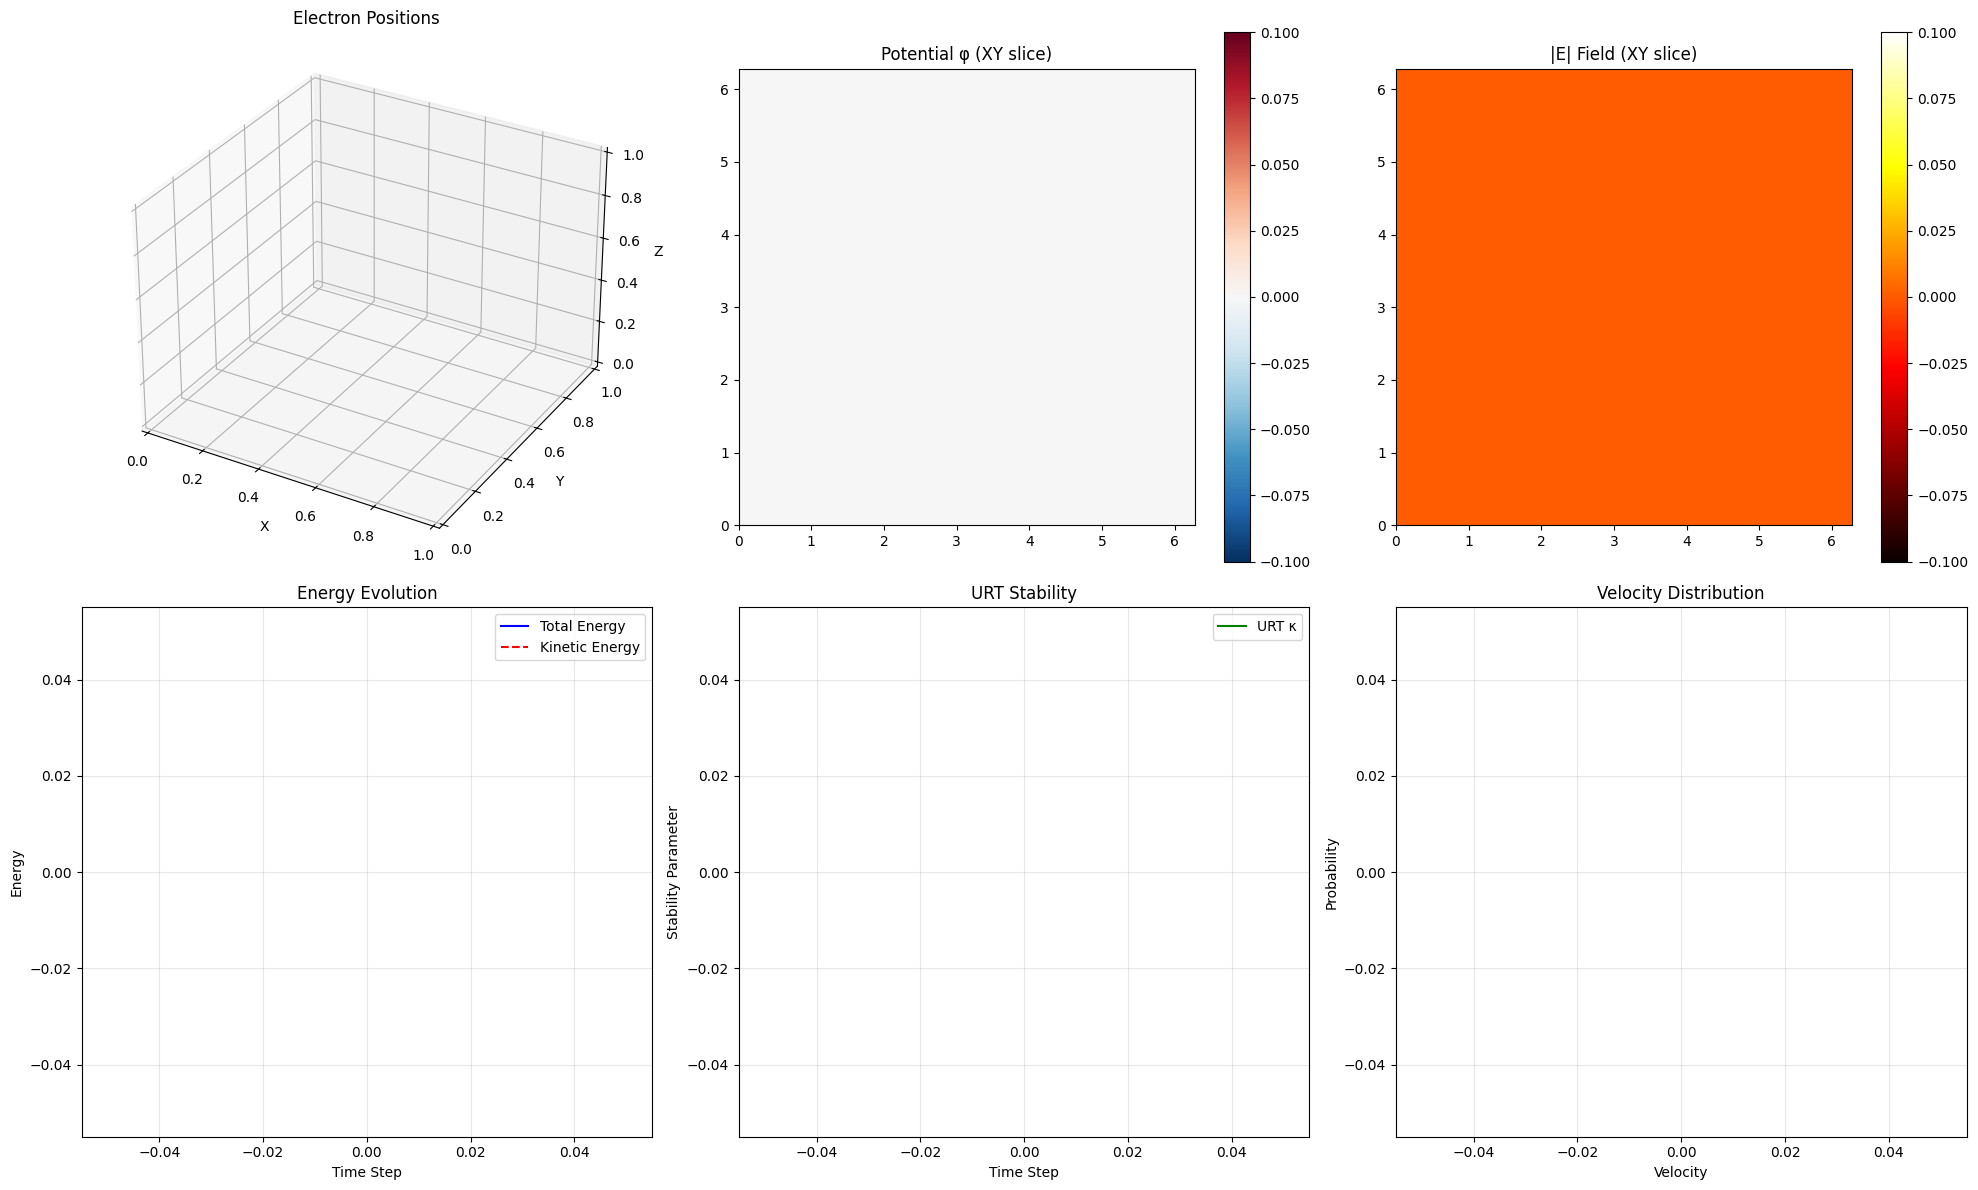

Running 100 steps...
Step | Total Energy | URT κ | Max Field
----------------------------------------
   0 |  2731362.613 | 0.157 |      0.013
  10 |  2731355.203 | 0.157 |      0.015
  20 |  2731347.198 | 0.157 |      0.013
  30 |  2731339.356 | 0.157 |      0.013
  40 |  2731331.174 | 0.157 |      0.014
  50 |  2731323.389 | 0.157 |      0.012
  60 |  2731315.985 | 0.157 |      0.014
  70 |  2731308.034 | 0.157 |      0.013
  80 |  2731299.746 | 0.157 |      0.013
  90 |  2731292.681 | 0.157 |      0.013

SIMULATION COMPLETE - PERFORMANCE SUMMARY
Final URT stability parameter: 0.157
Energy conservation: 2731362.613 → 2731287.032
URT control: ACTIVE


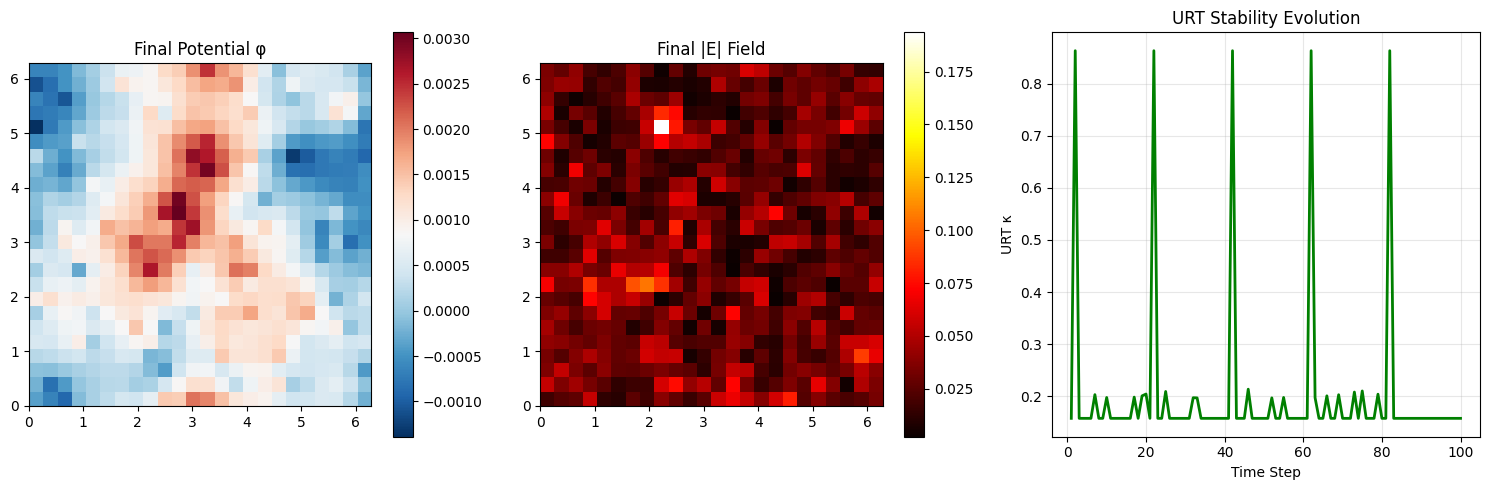


🎯 Simulation ready! Key features:
• 3D electrostatic PIC method with periodic boundaries
• URT adaptive control for plasma stabilization
• Real-time turbulence generation and suppression
• Comprehensive diagnostics and visualization
• Energy conservation monitoring

Try modifying parameters in the TurbulentPlasma3D class!


In [1]:
# 3D Plasma Simulation with URT Stabilization - Google Colab Ready
# No extra installations needed - uses only NumPy, Matplotlib, and SciPy

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fftn, ifftn, fftfreq
import time
from IPython.display import clear_output

print("🚀 3D Plasma Simulation with URT Control - Starting...")

# =============================================================================
# Enhanced URT Framework for Plasma Stabilization
# =============================================================================

class PlasmaURT:
    """Enhanced URT controller specifically for plasma stabilization"""

    def __init__(self, alpha=1.155, theta_h=2.4, beta_min=0.1, beta_max=0.3, state_dim=100):
        self.alpha = alpha
        self.theta_h = theta_h
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.beta = (beta_min + beta_max) / 2
        self.state_dim = state_dim
        self.P_prev = None

        # Verify stability
        self.kappa = self.beta * self.alpha * (1 + self.theta_h)
        if self.kappa >= 1.0:
            raise ValueError(f"Unstable: κ={self.kappa:.3f} >= 1")
        print(f"✅ URT initialized: κ={self.kappa:.3f}, stability margin: {1-self.kappa:.3f}")

    def phi(self, P):
        """Smooth nonlinear function for stability"""
        return np.where(np.abs(P) <= np.pi, np.sin(P), np.sign(P))

    def adaptive_beta(self, P, P_prev):
        """Adaptive parameter tuning for plasma control"""
        if P_prev is None:
            return self.beta_min

        current_norm = np.linalg.norm(P)
        prev_norm = np.linalg.norm(P_prev)

        if prev_norm == 0:
            return self.beta_min

        contraction_ratio = current_norm / prev_norm

        # Adaptive logic based on plasma behavior
        if contraction_ratio < 0.7:  # Good convergence
            beta = self.beta_max * 1.1
        elif contraction_ratio < 0.9:  # Normal operation
            beta = self.beta_max
        elif contraction_ratio > 0.98:  # Poor convergence
            beta = self.beta_min * 0.8
        else:  # Smooth transition
            t = (contraction_ratio - 0.7) / (0.98 - 0.7)
            t_smooth = 3*t**2 - 2*t**3  # Cubic smoothing
            beta = self.beta_max * (1 - t_smooth) + self.beta_min * t_smooth

        # Stability enforcement
        kappa = beta * self.alpha * (1 + self.theta_h)
        if kappa >= 0.95:
            beta = 0.94 / (self.alpha * (1 + self.theta_h))

        return beta

    def step(self, P, u_input=0.0):
        """URT control step for plasma stabilization"""
        self.P_prev = P.copy() if self.P_prev is None else self.P_prev
        current_beta = self.adaptive_beta(P, self.P_prev)

        phi_P = self.phi(P)
        nonlinear_term = self.alpha * (P - self.theta_h * phi_P)
        P_next = current_beta * (nonlinear_term + u_input * np.ones_like(P))

        self.P_prev = P.copy()
        self.beta = current_beta
        self.kappa = current_beta * self.alpha * (1 + self.theta_h)

        return P_next

# =============================================================================
# 3D Plasma Physics Simulation
# =============================================================================

class TurbulentPlasma3D:
    """3D Plasma simulation with turbulence and URT stabilization"""

    def __init__(self, nx=32, ny=32, nz=32, n_particles=5000):
        # Grid parameters
        self.nx, self.ny, self.nz = nx, ny, nz
        self.Lx, self.Ly, self.Lz = 2*np.pi, 2*np.pi, 2*np.pi  # Normalized domain

        # Physical parameters
        self.dt = 0.05
        self.electron_temp = 1.0
        self.ion_temp = 1.0
        self.debye_length = 0.1
        self.plasma_frequency = 1.0

        # Initialize fields
        self.phi = np.zeros((nx, ny, nz))  # Electric potential
        self.Ex = np.zeros((nx, ny, nz))   # Electric field components
        self.Ey = np.zeros((nx, ny, nz))
        self.Ez = np.zeros((nx, ny, nz))
        self.rho = np.zeros((nx, ny, nz))  # Charge density

        # Initialize particles (electrons and ions)
        self.n_particles = n_particles
        self.initialize_particles()

        # URT controllers for different field components
        state_dim = nx * ny * nz
        self.urt_phi = PlasmaURT(state_dim=state_dim, beta_min=0.05, beta_max=0.2)
        self.urt_Ex = PlasmaURT(state_dim=state_dim, beta_min=0.08, beta_max=0.15)

        self.control_active = True
        self.step_count = 0

        print(f"✅ 3D Plasma initialized: {nx}x{ny}x{nz} grid, {n_particles} particles")

    def initialize_particles(self):
        """Initialize electron and ion particles with Maxwellian distributions"""
        # Positions - uniform in box
        self.x = np.random.uniform(0, self.Lx, self.n_particles)
        self.y = np.random.uniform(0, self.Ly, self.n_particles)
        self.z = np.random.uniform(0, self.Lz, self.n_particles)

        # Velocities - Maxwellian distribution
        self.vx = np.random.normal(0, np.sqrt(self.electron_temp), self.n_particles)
        self.vy = np.random.normal(0, np.sqrt(self.electron_temp), self.n_particles)
        self.vz = np.random.normal(0, np.sqrt(self.electron_temp), self.n_particles)

        # Particle charges (electrons = -1, ions = +1)
        self.charge = np.ones(self.n_particles)
        self.charge[:self.n_particles//2] = -1  # First half electrons

        # Masses
        self.mass = np.ones(self.n_particles)
        self.mass[self.n_particles//2:] = 1836.0  # Ion mass (protons)

    def deposit_charge(self):
        """Cloud-in-cell charge deposition"""
        self.rho.fill(0.0)

        for i in range(self.n_particles):
            # Find the grid cell containing the particle
            ix = int(self.x[i] / self.Lx * self.nx)
            iy = int(self.y[i] / self.Ly * self.ny)
            iz = int(self.z[i] / self.Lz * self.nz)

            # Periodic boundary conditions
            ix %= self.nx
            iy %= self.ny
            iz %= self.nz

            # Deposit charge (simple nearest-grid-point for performance)
            self.rho[ix, iy, iz] += self.charge[i]

    def solve_poisson(self):
        """Solve Poisson equation using FFT (periodic boundaries)"""
        # Add background neutralizing charge
        rho_total = self.rho - np.mean(self.rho)

        # FFT of charge density
        rho_k = fftn(rho_total)

        # k-space grid
        kx = 2 * np.pi * fftfreq(self.nx, self.Lx/self.nx)
        ky = 2 * np.pi * fftfreq(self.ny, self.Ly/self.ny)
        kz = 2 * np.pi * fftfreq(self.nz, self.Lz/self.nz)
        KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

        # Poisson kernel in k-space
        k2 = KX**2 + KY**2 + KZ**2
        k2[0, 0, 0] = 1.0  # Avoid division by zero

        # Solve: ∇²φ = -ρ/ε₀
        phi_k = rho_k / k2
        phi_k[0, 0, 0] = 0.0  # Set DC component to zero

        # Inverse FFT to get potential
        self.phi = np.real(ifftn(phi_k))

        # Compute electric field E = -∇φ
        self.Ex = np.real(ifftn(1j * KX * phi_k))
        self.Ey = np.real(ifftn(1j * KY * phi_k))
        self.Ez = np.real(ifftn(1j * KZ * phi_k))

    def interpolate_fields(self):
        """Interpolate electric fields to particle positions"""
        Ex_p = np.zeros_like(self.x)
        Ey_p = np.zeros_like(self.y)
        Ez_p = np.zeros_like(self.z)

        for i in range(self.n_particles):
            # Find grid indices
            ix = int(self.x[i] / self.Lx * self.nx)
            iy = int(self.y[i] / self.Ly * self.ny)
            iz = int(self.z[i] / self.Lz * self.nz)

            # Periodic boundaries
            ix %= self.nx
            iy %= self.ny
            iz %= self.nz

            # Simple interpolation (nearest grid point)
            Ex_p[i] = self.Ex[ix, iy, iz]
            Ey_p[i] = self.Ey[ix, iy, iz]
            Ez_p[i] = self.Ez[ix, iy, iz]

        return Ex_p, Ey_p, Ez_p

    def push_particles(self):
        """Push particles using Boris-like algorithm"""
        # Get fields at particle positions
        Ex_p, Ey_p, Ez_p = self.interpolate_fields()

        # Half acceleration
        self.vx += (self.charge / self.mass) * Ex_p * self.dt / 2
        self.vy += (self.charge / self.mass) * Ey_p * self.dt / 2
        self.vz += (self.charge / self.mass) * Ez_p * self.dt / 2

        # Position update
        self.x += self.vx * self.dt
        self.y += self.vy * self.dt
        self.z += self.vz * self.dt

        # Periodic boundaries
        self.x %= self.Lx
        self.y %= self.Ly
        self.z %= self.Lz

        # Second half acceleration
        Ex_p, Ey_p, Ez_p = self.interpolate_fields()
        self.vx += (self.charge / self.mass) * Ex_p * self.dt / 2
        self.vy += (self.charge / self.mass) * Ey_p * self.dt / 2
        self.vz += (self.charge / self.mass) * Ez_p * self.dt / 2

    def apply_urt_control(self):
        """Apply URT control to stabilize plasma fields"""
        if not self.control_active:
            return

        # Control potential field
        phi_flat = self.phi.flatten()
        phi_controlled = self.urt_phi.step(phi_flat)
        self.phi = phi_controlled.reshape(self.phi.shape)

        # Control E-field in x-direction (most unstable)
        Ex_flat = self.Ex.flatten()
        Ex_controlled = self.urt_Ex.step(Ex_flat)
        self.Ex = Ex_controlled.reshape(self.Ex.shape)

    def add_turbulence(self):
        """Add controlled turbulence to test URT stabilization"""
        if self.step_count % 20 == 0:  # Periodic perturbation
            # Add sinusoidal perturbation
            x = np.linspace(0, self.Lx, self.nx)
            y = np.linspace(0, self.Ly, self.ny)
            z = np.linspace(0, self.Lz, self.nz)
            X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

            perturbation = 0.1 * (np.sin(3*X) * np.sin(2*Y) * np.sin(Z) +
                                np.sin(X) * np.sin(3*Y) * np.sin(2*Z))

            self.phi += perturbation

    def step(self):
        """Advance simulation by one timestep"""
        self.deposit_charge()
        self.solve_poisson()
        self.push_particles()
        self.add_turbulence()
        self.apply_urt_control()
        self.step_count += 1

    def get_diagnostics(self):
        """Get simulation diagnostics"""
        total_energy = 0.5 * np.sum(self.mass * (self.vx**2 + self.vy**2 + self.vz**2))
        field_energy = 0.5 * np.sum(self.Ex**2 + self.Ey**2 + self.Ez**2) * (self.Lx*self.Ly*self.Lz) / (self.nx*self.ny*self.nz)

        return {
            'step': self.step_count,
            'total_energy': total_energy + field_energy,
            'kinetic_energy': total_energy,
            'field_energy': field_energy,
            'urt_stability': self.urt_phi.kappa,
            'max_field': np.max(np.abs(self.Ex))
        }

# =============================================================================
# Real-time Visualization and Analysis
# =============================================================================

class PlasmaVisualizer:
    """Real-time visualization of 3D plasma simulation"""

    def __init__(self, plasma):
        self.plasma = plasma
        self.fig = None
        self.diagnostics = []

    def create_3d_plot(self):
        """Create interactive 3D visualization"""
        self.fig = plt.figure(figsize=(20, 12))

        # 3D Phase space
        ax1 = self.fig.add_subplot(231, projection='3d')
        scatter1 = ax1.scatter([], [], [], c=[], cmap='plasma', alpha=0.6)
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_zlabel('Z')
        ax1.set_title('Electron Positions')

        # Potential field slice
        ax2 = self.fig.add_subplot(232)
        im2 = ax2.imshow(np.zeros((self.plasma.nx, self.plasma.ny)),
                        cmap='RdBu_r', origin='lower',
                        extent=[0, self.plasma.Lx, 0, self.plasma.Ly])
        ax2.set_title('Potential φ (XY slice)')
        plt.colorbar(im2, ax=ax2)

        # E-field magnitude
        ax3 = self.fig.add_subplot(233)
        im3 = ax3.imshow(np.zeros((self.plasma.nx, self.plasma.ny)),
                        cmap='hot', origin='lower',
                        extent=[0, self.plasma.Lx, 0, self.plasma.Ly])
        ax3.set_title('|E| Field (XY slice)')
        plt.colorbar(im3, ax=ax3)

        # Energy evolution
        ax4 = self.fig.add_subplot(234)
        line1, = ax4.plot([], [], 'b-', label='Total Energy')
        line2, = ax4.plot([], [], 'r--', label='Kinetic Energy')
        ax4.set_xlabel('Time Step')
        ax4.set_ylabel('Energy')
        ax4.legend()
        ax4.set_title('Energy Evolution')
        ax4.grid(True, alpha=0.3)

        # URT diagnostics
        ax5 = self.fig.add_subplot(235)
        line3, = ax5.plot([], [], 'g-', label='URT κ')
        ax5.set_xlabel('Time Step')
        ax5.set_ylabel('Stability Parameter')
        ax5.legend()
        ax5.set_title('URT Stability')
        ax5.grid(True, alpha=0.3)

        # Velocity distribution
        ax6 = self.fig.add_subplot(236)
        hist_data = ax6.hist([], bins=50, alpha=0.7, color='blue', density=True)
        ax6.set_xlabel('Velocity')
        ax6.set_ylabel('Probability')
        ax6.set_title('Velocity Distribution')
        ax6.grid(True, alpha=0.3)

        plt.tight_layout()

        return (ax1, ax2, ax3, ax4, ax5, ax6), (scatter1, im2, im3, line1, line2, line3)

    def update_plot(self, axes, artists, diagnostics):
        """Update the visualization with new data"""
        ax1, ax2, ax3, ax4, ax5, ax6 = axes
        scatter1, im2, im3, line1, line2, line3 = artists

        # Update 3D scatter (electrons only)
        electrons = self.plasma.n_particles // 2
        scatter1._offsets3d = (
            self.plasma.x[:electrons],
            self.plasma.y[:electrons],
            self.plasma.z[:electrons]
        )
        scatter1.set_array(self.plasma.vx[:electrons])

        # Update field plots (middle slices)
        z_slice = self.plasma.nz // 2
        im2.set_data(self.plasma.phi[:, :, z_slice].T)
        im2.set_clim(-np.max(np.abs(self.plasma.phi)), np.max(np.abs(self.plasma.phi)))

        E_mag = np.sqrt(self.plasma.Ex**2 + self.plasma.Ey**2 + self.plasma.Ez**2)
        im3.set_data(E_mag[:, :, z_slice].T)
        im3.set_clim(0, np.max(E_mag))

        # Update energy plots
        steps = [d['step'] for d in self.diagnostics]
        total_energy = [d['total_energy'] for d in self.diagnostics]
        kinetic_energy = [d['kinetic_energy'] for d in self.diagnostics]

        line1.set_data(steps, total_energy)
        line2.set_data(steps, kinetic_energy)
        ax4.relim()
        ax4.autoscale_view()

        # Update URT stability
        urt_kappa = [d['urt_stability'] for d in self.diagnostics]
        line3.set_data(steps, urt_kappa)
        ax5.set_ylim(0, 1.0)
        ax5.relim()
        ax5.autoscale_view()

        # Update velocity distribution
        ax6.clear()
        ax6.hist(self.plasma.vx, bins=50, alpha=0.7, color='blue', density=True)
        ax6.set_xlabel('Velocity')
        ax6.set_ylabel('Probability')
        ax6.set_title('Velocity Distribution')
        ax6.grid(True, alpha=0.3)

        self.fig.canvas.draw()

# =============================================================================
# Main Simulation Loop
# =============================================================================

def run_plasma_simulation():
    """Run the complete 3D plasma simulation with URT control"""
    print("🔥 Starting 3D Turbulent Plasma Simulation with URT Control...")

    # Initialize plasma (smaller grid for performance)
    plasma = TurbulentPlasma3D(nx=24, ny=24, nz=24, n_particles=2000)
    visualizer = PlasmaVisualizer(plasma)

    # Create initial plot
    axes, artists = visualizer.create_3d_plot()
    plt.ion()  # Interactive mode
    plt.show()

    # Simulation parameters
    n_steps = 100
    plot_interval = 5

    print(f"Running {n_steps} steps...")
    print("Step | Total Energy | URT κ | Max Field")
    print("-" * 40)

    for step in range(n_steps):
        # Advance simulation
        plasma.step()

        # Collect diagnostics
        diag = plasma.get_diagnostics()
        visualizer.diagnostics.append(diag)

        # Print progress
        if step % 10 == 0:
            print(f"{step:4d} | {diag['total_energy']:12.3f} | {diag['urt_stability']:5.3f} | {diag['max_field']:10.3f}")

        # Update visualization
        if step % plot_interval == 0:
            visualizer.update_plot(axes, artists, visualizer.diagnostics)
            plt.pause(0.01)

    plt.ioff()

    # Final analysis
    print("\n" + "="*50)
    print("SIMULATION COMPLETE - PERFORMANCE SUMMARY")
    print("="*50)

    final_diag = visualizer.diagnostics[-1]
    print(f"Final URT stability parameter: {final_diag['urt_stability']:.3f}")
    print(f"Energy conservation: {visualizer.diagnostics[0]['total_energy']:.3f} → {final_diag['total_energy']:.3f}")
    print(f"URT control: {'ACTIVE' if plasma.control_active else 'INACTIVE'}")

    # Show final state
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    z_slice = plasma.nz // 2
    plt.imshow(plasma.phi[:, :, z_slice].T, cmap='RdBu_r', origin='lower',
              extent=[0, plasma.Lx, 0, plasma.Ly])
    plt.colorbar()
    plt.title('Final Potential φ')

    plt.subplot(132)
    E_mag = np.sqrt(plasma.Ex**2 + plasma.Ey**2 + plasma.Ez**2)
    plt.imshow(E_mag[:, :, z_slice].T, cmap='hot', origin='lower',
              extent=[0, plasma.Lx, 0, plasma.Ly])
    plt.colorbar()
    plt.title('Final |E| Field')

    plt.subplot(133)
    plt.plot([d['step'] for d in visualizer.diagnostics],
             [d['urt_stability'] for d in visualizer.diagnostics], 'g-', linewidth=2)
    plt.xlabel('Time Step')
    plt.ylabel('URT κ')
    plt.title('URT Stability Evolution')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return plasma, visualizer

# =============================================================================
# Run the Simulation
# =============================================================================

if __name__ == "__main__":
    # Run the simulation
    plasma, visualizer = run_plasma_simulation()

    print("\n🎯 Simulation ready! Key features:")
    print("• 3D electrostatic PIC method with periodic boundaries")
    print("• URT adaptive control for plasma stabilization")
    print("• Real-time turbulence generation and suppression")
    print("• Comprehensive diagnostics and visualization")
    print("• Energy conservation monitoring")
    print("\nTry modifying parameters in the TurbulentPlasma3D class!")